# Terzaghi 1D Multi-Layer

Demo for the 1D Multi layer FEM model to get settlement.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2
import os
import sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terzaghi_1d_multi.fem import Get_terzaghi1dMultilayer_FEA
from src.plotting.terzaghi_1d.plot import Get_Settlement_Plot

sns.set_theme(style="whitegrid")

load = 100.0
base = 2.5
num = 100
depths = [1.0, 2.0, 4.0, 5.0]
Cv = [2e-7, 2e-7, 1e-7, 3e-7]
Mv = [5e-4, 8e-4, 6e-4, 4e-4]
T = (24 * 60 * 60) * 365
time_steps = 1000
use_uniform_u0 = False

H = max(depths)
nodes = num + 1
z = -np.linspace(0.0, H, nodes)
time_day = np.linspace(0.0, T / (60 * 60 * 24), time_steps)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Solve the Multilayer Model

u_hist shape:             (1000, 101)
settlement_history shape: (1000,)
Final settlement:         0.117966 m
Total Settlement:         0.179721


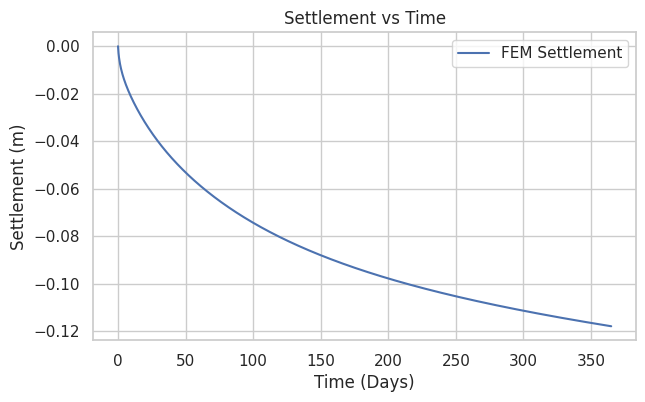

In [12]:
settlement_history, u_hist, settlement_profile = Get_terzaghi1dMultilayer_FEA( depths, num, load, T, time_steps, Cv, Mv, Base=base, U0=False)

print(f"u_hist shape:             {u_hist.shape}")
print(f"settlement_history shape: {settlement_history.shape}")
print(f"Final settlement:         {settlement_history[-1]:.6f} m")
print(f"Total Settlement:         {np.sum(settlement_profile):.6f}")

fig, ax = Get_Settlement_Plot( settlement_history , time_day)